# LLZO DeepMD Workflow Notebook

In [9]:
#Basic information
from ase.io import read

atoms = read("Li7La3Zr2O12.poscar", format="vasp")
print(atoms)
print("Number of atoms:", len(atoms))
print("Chemical formula:", atoms.get_chemical_formula())
print("Cell:")
print(atoms.cell)

Atoms(symbols='La24Li56O96Zr16', pbc=True, cell=[[13.23607, 0.0, 8e-16], [-8e-16, 13.23607, 8e-16], [0.0, 0.0, 12.701706]])
Number of atoms: 192
Chemical formula: La24Li56O96Zr16
Cell:
Cell([[13.23607, 0.0, 8e-16], [-8e-16, 13.23607, 8e-16], [0.0, 0.0, 12.701706]])


## 1. Pseudo used in Quantum ESPRESSO(QE)

The DFT calculations used QE with low accuracy(efficient) SSSP PBE pseudopotentials.

Directory:
```text
./pseudo
```
QE cutoffs:
```text
ecutwfc = 50 Ry
ecutrho = 400 Ry
```

## 2. Generate QE inputs: original + perturbed structures

Perturbation settings:

```text
Number of perturbed structures = 5
Random displacement sigma = 0.02 Å
QE calculation = AIMD
K-points = Gamma
```
https://www.quantum-espresso.org/Doc/INPUT_PW.html

*In order to have a quick AIMD result, 3 small structure were choose to test instead of using LLZO

In [11]:
from ase.io import read, write
import numpy as np
from pathlib import Path
import copy
import re

# Input/output directories
structures_dir = Path("./structure")
out_root = Path("./qe_inputs_by_structure")
out_root.mkdir(exist_ok=True)

# Random perturbation settings
sigma = 0.02
n_structures = 5
random_seed = 123
rng = np.random.default_rng(random_seed)

# AIMD test settings
nstep = 50
temperature = 300
dt_au = 20.0

base_input_data = {
    "control": {
        "calculation": "md",
        "prefix": "aimd",
        "outdir": "./tmp",
        "pseudo_dir": "./pseudo",
        "tstress": True,
        "tprnfor": True,
        "nstep": nstep,
        "dt": dt_au,
    },
    "system": {
        "ecutwfc": 50,
        "ecutrho": 400,
        "occupations": "fixed",
        "nosym": True,
        "noinv": True,
    },
    "electrons": {
        "conv_thr": 1.0e-6,
    },
    "ions": {
        "ion_dynamics": "verlet",
        "ion_temperature": "rescaling",
        "tempw": temperature,
        "pot_extrapolation": "second_order",
        "wfc_extrapolation": "second_order",
    },
}

pseudopotentials = {
    "Li": "li_pbe_v1.4.uspp.F.UPF",
    "La": "La.paw.z_11.atompaw.wentzcovitch.v1.2.upf",
    "Zr": "Zr_pbe_v1.uspp.F.UPF",
    "O": "O.pbe-n-kjpaw_psl.0.1.UPF",
    "P": "P.pbe-n-rrkjus_psl.1.0.0.UPF",
}

def safe_name(name: str) -> str:
    name = Path(name).stem
    name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    return name

def force_gamma_kpoints(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    new_lines = []
    i = 0
    while i < len(lines):
        if lines[i].strip().startswith("K_POINTS"):
            new_lines.append("K_POINTS gamma\n")
            i += 2
        else:
            new_lines.append(lines[i])
            i += 1

    with open(filename, "w") as f:
        f.writelines(new_lines)

def check_pseudos(atoms):
    symbols = sorted(set(atoms.get_chemical_symbols()))
    missing = [s for s in symbols if s not in pseudopotentials]
    if missing:
        raise ValueError(f"Missing pseudopotentials for elements: {missing}")

def write_qe_input(filename, atoms, prefix):
    input_data = copy.deepcopy(base_input_data)
    input_data["control"]["prefix"] = prefix
    input_data["control"]["outdir"] = f"./tmp/{prefix}"

    write(
        filename,
        atoms,
        format="espresso-in",
        input_data=input_data,
        pseudopotentials=pseudopotentials,
        kpts=(1, 1, 1),
    )

    force_gamma_kpoints(filename)

poscar_files = sorted(structures_dir.glob("*.poscar"))

if not poscar_files:
    raise FileNotFoundError(f"No *.poscar files found in {structures_dir.resolve()}")

for poscar in poscar_files:
    material_name = safe_name(poscar.name)
    material_dir = out_root / material_name
    material_dir.mkdir(parents=True, exist_ok=True)

    atoms0 = read(poscar, format="vasp")
    check_pseudos(atoms0)

    original_prefix = f"{material_name}_md_original"
    write_qe_input(
        material_dir / f"{original_prefix}.in",
        atoms0,
        original_prefix,
    )

    for i in range(n_structures):
        atoms = atoms0.copy()
        atoms.positions += rng.normal(
            loc=0.0,
            scale=sigma,
            size=atoms.positions.shape,
        )

        prefix = f"{material_name}_md_perturb_{i+1:03d}"
        write_qe_input(
            material_dir / f"{prefix}.in",
            atoms,
            prefix,
        )

    print(f"[OK] {poscar.name}: generated original + {n_structures} perturbed inputs in {material_dir}")

print("\nAll QE AIMD input files generated.")
print(f"Input structures: {structures_dir}")
print(f"Output root: {out_root}")
print(f"AIMD settings: nstep = {nstep}, T = {temperature} K, dt = {dt_au} a.u.")

[OK] Li2O_mp-13725.poscar: generated original + 5 perturbed inputs in qe_inputs_by_structure/Li2O_mp-13725
[OK] Li2O_mp-1960.poscar: generated original + 5 perturbed inputs in qe_inputs_by_structure/Li2O_mp-1960
[OK] Li3PO4.poscar: generated original + 5 perturbed inputs in qe_inputs_by_structure/Li3PO4

All QE AIMD input files generated.
Input structures: structure
Output root: qe_inputs_by_structure
AIMD settings: nstep = 50, T = 300 K, dt = 20.0 a.u.


In [ ]:
## 3. Run QE AIMD calculations
chmod +x run_all_qe.sh
./run_all_qe.sh

## 4. Extract QE output frames into a DeepMD dataset

1. Read QE outputs with ASE as `espresso-out`.
2. Save all valid frames as `llzo_all.traj`.
3. Convert the ASE trajectory to DeepMD `npy` format using `dpdata`.

In [14]:
from ase.io import read, write
from pathlib import Path
import dpdata
import os
from collections import defaultdict

search_root = Path("qe_inputs_by_structure")
out_files = sorted(search_root.glob("*/*.out"))

groups = defaultdict(list)
summary_lines = []

for f in out_files:
    print("=" * 80)
    print("Reading:", f)

    try:
        frames = read(str(f), index=":", format="espresso-out")
        if not isinstance(frames, list):
            frames = [frames]
    except Exception as e:
        print("[READ_FAILED]", f, e)
        continue

    valid_frames = []
    for atoms in frames:
        try:
            atoms.get_potential_energy()
            atoms.get_forces()
            valid_frames.append(atoms)
        except Exception:
            pass

    print("Total frames read:", len(frames))
    print("Valid frames with energy/forces:", len(valid_frames))

    # group by parent folder, e.g. Li2O, Li3PO4, Li2ZrO3
    system_name = f.parent.name
    groups[system_name].extend(valid_frames)

    summary_lines.append(
        f"{f} | frames_read={len(frames)} | valid_frames={len(valid_frames)}"
    )

with open("extract_qe_summary.txt", "w") as f:
    f.write("\n".join(summary_lines))

os.makedirs("deepmd_dataset", exist_ok=True)

for system_name, frames in groups.items():
    if len(frames) == 0:
        continue

    print("=" * 80)
    print(f"System: {system_name}")
    print(f"Frames: {len(frames)}")
    print(f"Atoms per frame: {len(frames[0])}")

    traj_file = f"{system_name}.traj"
    write(traj_file, frames)

    out_dir = f"deepmd_dataset/{system_name}"
    os.makedirs(out_dir, exist_ok=True)

    dataset = dpdata.LabeledSystem(traj_file, fmt="ase/traj")
    dataset.to("deepmd/npy", out_dir)

    print(f"Saved: {out_dir}")

print("Done.")

Reading: qe_inputs_by_structure/Li2O_mp-13725/Li2O_mp-13725_md_original.out
[READ_FAILED] qe_inputs_by_structure/Li2O_mp-13725/Li2O_mp-13725_md_original.out ((2, 0), 1)
Reading: qe_inputs_by_structure/Li2O_mp-13725/Li2O_mp-13725_md_perturb_001.out
Total frames read: 50
Valid frames with energy/forces: 50
Reading: qe_inputs_by_structure/Li2O_mp-13725/Li2O_mp-13725_md_perturb_002.out
Total frames read: 50
Valid frames with energy/forces: 50
Reading: qe_inputs_by_structure/Li2O_mp-13725/Li2O_mp-13725_md_perturb_003.out
Total frames read: 50
Valid frames with energy/forces: 50
Reading: qe_inputs_by_structure/Li2O_mp-13725/Li2O_mp-13725_md_perturb_004.out
Total frames read: 50
Valid frames with energy/forces: 50
Reading: qe_inputs_by_structure/Li2O_mp-13725/Li2O_mp-13725_md_perturb_005.out
Total frames read: 50
Valid frames with energy/forces: 50
Reading: qe_inputs_by_structure/Li2O_mp-1960/Li2O_mp-1960_md_original.out
Total frames read: 50
Valid frames with energy/forces: 50
Reading: qe_in

## 5. DeepMD training input

Main settings:

```text
descriptor = se_e2_a
rcut = 6.0 Å
rcut_smth = 5.5 Å
descriptor net = [25, 50, 100]
fitting net = [240, 240, 240]
batch_size = 1
training steps = 200000
```

Virial was not trained:

```text
start_pref_v = 0
limit_pref_v = 0
```

In [15]:
import json
from pathlib import Path

# Automatically collect all DeepMD system folders
deepmd_root = Path("deepmd_dataset")
systems = sorted([
    str(p) for p in deepmd_root.iterdir()
    if p.is_dir()
])

if not systems:
    raise RuntimeError("No DeepMD system folders found in deepmd_dataset/")

print("Found systems:")
for s in systems:
    print("  ", s)

input_json = {
    "model": {
        "type_map": ["Li", "O", "P", "Zr"],
        "descriptor": {
            "type": "se_e2_a",
            "sel": [60, 60, 60, 60],
            "rcut": 6.0,
            "rcut_smth": 5.5,
            "neuron": [25, 50, 100],
            "axis_neuron": 16
        },
        "fitting_net": {
            "neuron": [240, 240, 240],
            "resnet_dt": True
        }
    },
    "learning_rate": {
        "type": "exp",
        "start_lr": 0.001,
        "decay_steps": 5000,
        "decay_rate": 0.95
    },
    "loss": {
        "start_pref_e": 0.02,
        "limit_pref_e": 1,
        "start_pref_f": 1000,
        "limit_pref_f": 1,
        "start_pref_v": 0,
        "limit_pref_v": 0
    },
    "training": {
        "training_data": {
            "systems": systems,
            "batch_size": 1
        },
        "validation_data": {
            "systems": systems,
            "batch_size": 1,
            "numb_btch": 1
        },
        "numb_steps": 20000,
        "disp_file": "lcurve.out",
        "disp_freq": 100,
        "save_freq": 2000
    }
}

with open("input.json", "w") as f:
    json.dump(input_json, f, indent=2)

print("\ninput.json written.")

Found systems:
   deepmd_dataset/Li2O_mp-13725
   deepmd_dataset/Li2O_mp-1960
   deepmd_dataset/Li3PO4

input.json written.


## 5. Train, freeze, and test the model

Training:

```bash
dp train input.json
```

Freeze:

```bash
dp freeze -o frozen_model.pb
```

Test:

```bash
dp test -m frozen_model.pb -s deepmd_dataset -d detail
```

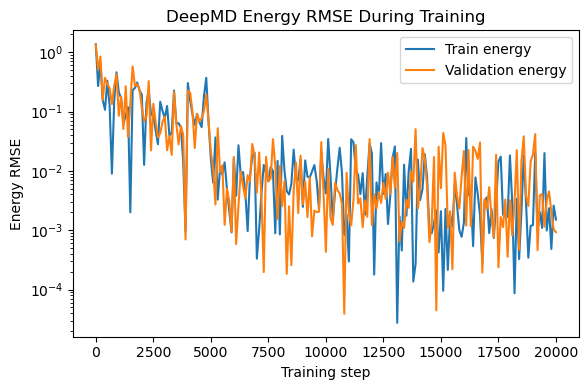

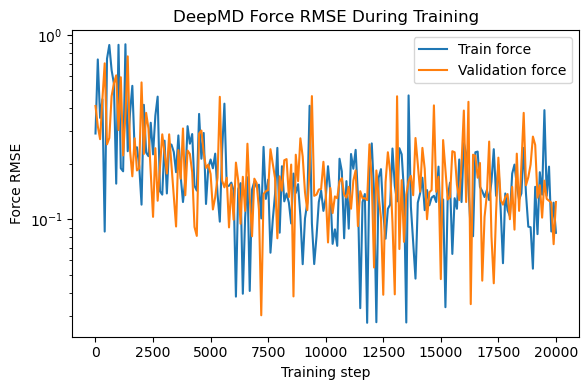

In [30]:
# Energy RMSE
plt.figure(figsize=(6,4))
plt.plot(df["step"], df["rmse_e_trn"], label="Train energy")
plt.plot(df["step"], df["rmse_e_val"], label="Validation energy")
plt.xlabel("Training step")
plt.ylabel("Energy RMSE")
plt.title("DeepMD Energy RMSE During Training")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

# Force RMSE
plt.figure(figsize=(6,4))
plt.plot(df["step"], df["rmse_f_trn"], label="Train force")
plt.plot(df["step"], df["rmse_f_val"], label="Validation force")
plt.xlabel("Training step")
plt.ylabel("Force RMSE")
plt.title("DeepMD Force RMSE During Training")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

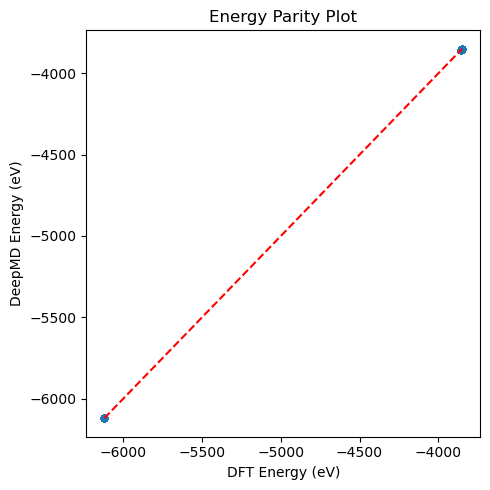

In [31]:
import numpy as np
import matplotlib.pyplot as plt

e = np.loadtxt("detail.e.out")

ref = e[:,0]
pred = e[:,1]

plt.figure(figsize=(5,5))

plt.scatter(ref, pred, s=20)

xmin = min(ref.min(), pred.min())
xmax = max(ref.max(), pred.max())

plt.plot([xmin, xmax], [xmin, xmax], 'r--')

plt.xlabel("DFT Energy (eV)")
plt.ylabel("DeepMD Energy (eV)")
plt.title("Energy Parity Plot")

plt.tight_layout()
plt.show()

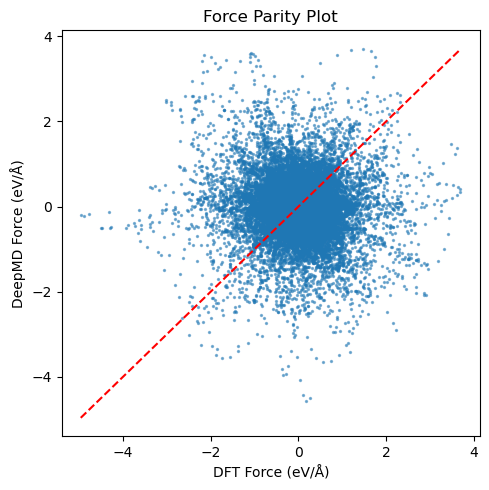

In [32]:
import numpy as np
import matplotlib.pyplot as plt

f = np.loadtxt("detail.f.out")

ref = np.concatenate([
    f[:,0],
    f[:,2],
    f[:,4]
])

pred = np.concatenate([
    f[:,1],
    f[:,3],
    f[:,5]
])

plt.figure(figsize=(5,5))

plt.scatter(ref, pred, s=2, alpha=0.5)

xmin = min(ref.min(), pred.min())
xmax = max(ref.max(), pred.max())

plt.plot([xmin, xmax], [xmin, xmax], 'r--')

plt.xlabel("DFT Force (eV/Å)")
plt.ylabel("DeepMD Force (eV/Å)")
plt.title("Force Parity Plot")

plt.tight_layout()
plt.show()

## 6. LAMMPS + DeepMD plugin setup

The standard LAMMPS executable initially did not recognize `pair_style deepmd`. The plugin library was found at:

```text
/apps/conda/lib/libdeepmd_lmp.so
```

Working LAMMPS setup:

```lammps
plugin load /apps/conda/lib/libdeepmd_lmp.so
```

Runtime environment:

```bash
export OMP_NUM_THREADS=1
export DP_INTRA_OP_PARALLELISM_THREADS=4
export DP_INTER_OP_PARALLELISM_THREADS=2
lmp_mpi -in md_test.in
```

In [ ]:
# lammps input file md_test.in
plugin load /apps/conda/lib/libdeepmd_lmp.so

units           metal
atom_style      atomic
boundary        p p p

read_data       Li2O_mp-1960.data

mass 1 6.94
mass 2 15.999

pair_style      deepmd frozen_model.pb
pair_coeff      * *

neighbor        2.0 bin
neigh_modify    every 1 delay 0 check yes

timestep        0.00025

velocity        all create 300 12345 mom yes rot yes dist gaussian

fix             1 all nvt temp 300 300 0.05

thermo          50
thermo_style    custom step temp pe ke etotal

dump            1 all atom 50 traj_li2o_300K.lammpstrj

run             8000

unfix           1
undump          1

In [20]:
#Convert to lammps input to test
from ase.io import read, write

atoms = read(
    "structure/Li2O_mp-1960.poscar",
    format="vasp"
)

write(
    "Li2O_mp-1960.data",
    atoms,
    format="lammps-data",
    atom_style="atomic",
    specorder=["Li", "O"]
)

print("Li2O_mp-1960.data written with type order: Li O")

Li2O_mp-1960.data written with type order: Li O


    Step       Temp     PotEng    KinEng     TotEng
0    0.0  300.00000 -3854.1706  0.426558 -3853.7440
1   50.0  121.95144 -3853.9118  0.173398 -3853.7384
2  100.0  128.54519 -3853.8844  0.182773 -3853.7017
3  150.0  188.40637 -3853.9262  0.267888 -3853.6583
4  200.0  190.17257 -3853.8597  0.270399 -3853.5893
       Step       Temp     PotEng    KinEng     TotEng
156  7800.0  372.01456 -3861.1284  0.528953 -3860.5994
157  7850.0  363.60483 -3861.0335  0.516996 -3860.5165
158  7900.0  267.22612 -3860.8161  0.379959 -3860.4361
159  7950.0  395.43780 -3861.0299  0.562258 -3860.4676
160  8000.0  342.47940 -3860.9526  0.486958 -3860.4656


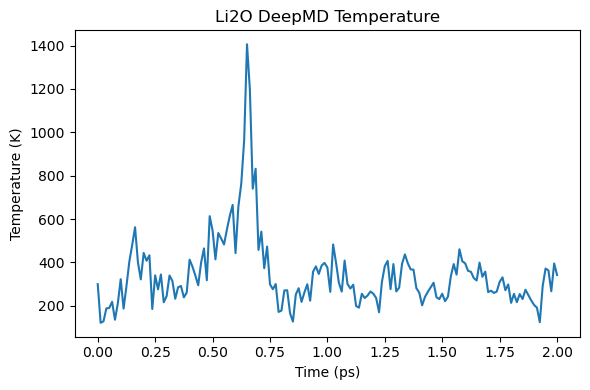

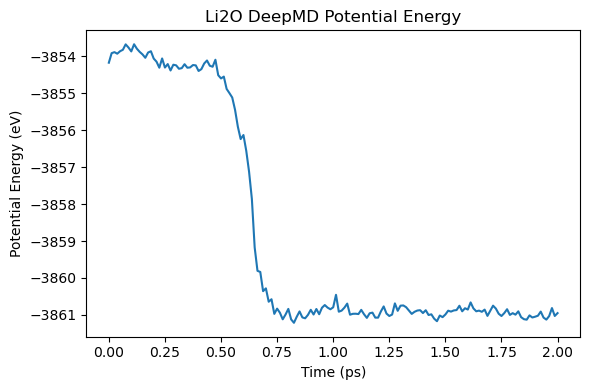

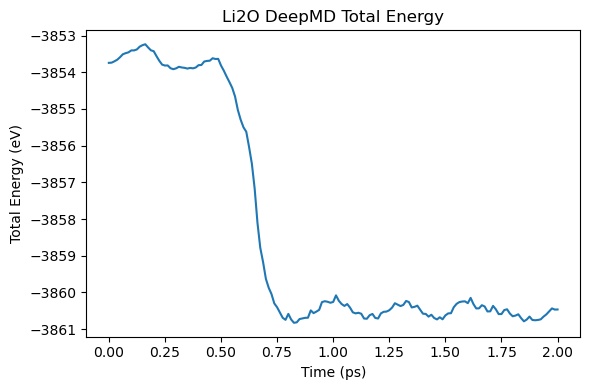

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

log_file = "log.lammps"

rows = []
headers = None

with open(log_file, "r") as f:

    for line in f:

        line = line.strip()

        if line.startswith("Step"):
            headers = line.split()
            continue

        if headers is not None:

            parts = line.split()

            if len(parts) != len(headers):
                continue

            try:
                rows.append([float(x) for x in parts])
            except:
                pass

df = pd.DataFrame(rows, columns=headers)

print(df.head())
print(df.tail())

df["Time_ps"] = df["Step"] * 0.00025

# Temperature
plt.figure(figsize=(6,4))
plt.plot(df["Time_ps"], df["Temp"])
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.title("Li2O DeepMD Temperature")
plt.tight_layout()
plt.show()

# Potential energy
plt.figure(figsize=(6,4))
plt.plot(df["Time_ps"], df["PotEng"])
plt.xlabel("Time (ps)")
plt.ylabel("Potential Energy (eV)")
plt.title("Li2O DeepMD Potential Energy")
plt.tight_layout()
plt.show()

# Total energy
plt.figure(figsize=(6,4))
plt.plot(df["Time_ps"], df["TotEng"])
plt.xlabel("Time (ps)")
plt.ylabel("Total Energy (eV)")
plt.title("Li2O DeepMD Total Energy")
plt.tight_layout()
plt.show()